# <a id='toc1_'></a>[Regularização L1 e L2: escolhendo uma solução entre dados redundantes](#toc0_)

Autor: Vinícius Marianno de Marque Cutolo

RM: 2610042

Professor: Daniel Roberto Cassar

**Sumário**<a id='toc0_'></a>    
- [Regularização L1 e L2: escolhendo uma solução entre dados redundantes](#toc1_)    
    - [Introdução](#toc1_1_1_)    
    - [Regressão Linear simples](#toc1_1_2_)    
    - [Evidenciação do problema](#toc1_1_3_)    
      - [Sistemas mal-condicionados](#toc1_1_3_1_)    
      - [Sistemas sub-determinados](#toc1_1_3_2_)    
    - [L2: penalização nos pesos](#toc1_1_4_)    
    - [L1: regularização geométrica](#toc1_1_5_)    
    - [Exemplos teóricos](#toc1_1_6_)    
      - [Valor de casas em terrenos](#toc1_1_6_1_)    
      - [Sistema Linear possível e indeterminado](#toc1_1_6_2_)    
    - [Exemplo prático - EEG para prever tendência de movimento](#toc1_1_7_)    
      - [Pegando os dados do Dataset](#toc1_1_7_1_)    
      - [Tratando o EEG](#toc1_1_7_2_)    
      - [Separação de dados em treino e teste](#toc1_1_7_3_)    
      - [Modelos preditivos](#toc1_1_7_4_)    
    - [Apêndice](#toc1_1_8_)    
    - [Referências](#toc1_1_9_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

### <a id='toc1_1_1_'></a>[Introdução](#toc0_)


Imagine uma regressão linear $\hat{y}=Xw$ e uma função de erro quadrático $J(w)=||y-Xw||_2^2$. Treinar um modelo significa minimizar $J(w)$ e achar o $w$ que melhor explica o problema, porém, nos deparamos com um grande problema.

Imagine que os termos de $X$ não sejam independente, existe uma correlação entre eles e alguns são até redundantes. Isso ocorre principalmente quando há correlação forte entre os atributos ou uma quantidade muito maior de atributos do que exemplos, chamados de sistemas mal-condicionados (quando há uma correlação muito forte entre os termos) e sub-determinados (quando há muito mais atributos do que exemplos). 

Ambas as condições são definidas de forma simplificada, mal-condicionamento tem relação com a colinearidade das colunas da matriz de teste (algumas colunas podem ser aproximadas como combinações lineares das outra). Enquanto isso, sub-determinação nao só sobre disparidade entre atributos e exemplos, seria sobre a diferença entre exemplos linearmente independentes e incógnitas no nosso sistema. Com isso explicado, vamos nos referir a forma simplificada das condições daqui para frente, com o objetivo de tornar essa jornada mais didática.

Para aprofundar esses problemas, algumas células de código foram criadas para mostrar, graficamente, como que esse problema existe. 

Como exemplo de cada caso, situações simples serão usadas para nos aprofundarmos na solução por L1 e L2. Para o caso mal-condicionado, iremos tentar prever o valor de uma casa usando a área em pés quadrados e em metros quadrados. Para o caso sub-determinado, continuaremos na algebra linear: prever o resultado de três parâmetros tendo somente duas equações que os correlacione. Cada qual será desenvolvido mais em suas respectivas sessões.

Enfim, para testar a aplicabilidade dessa técnica, trataremos de um exemplo pratico a ser resolvido: interpretação de leitura de eletroencefalograma (EEG) para previsão de velocidade do punho. Esse problema é interessante pois os canais são fortemente correlacionados espacialmente, mal-condicionado, e há exemplos muito ruidosos. Ademais, existe muita redundância de informações dentro do sistema, podendo ser ou nao ser um caso de sub-determinação, mas não podemos garantir isso. Com isso, chegamos à pergunta motivadora:

*Dado que existem vários w's que explicam igualmente, ou quase igualmente, bem o problema, qual devemos escolher?*

Claro, a resposta poderia ser simplesmente 'aquele que diminua o erro', mas a regularização adiciona uma outra preferência. Ao invés de reduzir $J(w)$, a regularização L1 e L2 preza por reduzir (1).

$$
(1)\qquad J(w)+\lambda R(w) \qquad 
$$
<a id='toc0_'></a>[[1]](#toceq_1_) [[3]](#toceq_3_)

em que:

1. $J(w)$ ajusta os dados
2. $R(w)$ penaliza os parâmetros
3. $\lambda$ representa o compromisso entre o ajuste dos dados e a regularização de $R(w)$

Aos que ainda não estão familiarizados com a formula, aguarde até a próxima sessão [Regressão Linear simples](#toc1_1_2_) que isso será melhor explicado. Aviso de antemão que o leitor deve ter um conhecimento mínimo de algebra linear para entender algumas das discussões, em especial, a noção que sistemas lineares podem ser escritos na forma matricial $X\omega = \hat{y}$. Com $X$ sendo a tabela de dados, $\omega$ sendo o vetor de pesos da resposta e $\hat{y}$ o vetor resposta.

Uma das maiores utilidades dessa técnica é evitar algo denominado de overfitting,que é um fenômeno que ocorre quando um modelo se ajusta muito aos dados fornecidos e não consegue generalizar para outros <a id='toc0_'></a>[[2]](#toceq_2_). Isso ocorre porque a regularização permite mudar a preferencia estrutural do problema <a id='toc0_'></a>[[3]](#toceq_3_), que impedem uma supervalorização da interpolação pura. Contudo, a regularização L1 e L2 não está restrita a ser somente uma técnica para evitar overfitting, a sua aplicação gera um restrição do próprio espaço de soluções, sendo ótimo para forçar condições de contorno na estrutura da solução.

A seguir, o notebook irá seguir a seguinte forma:

Regressão Linear $\rightarrow$ Evidenciação do problema $\rightarrow$ L2 $\rightarrow$ L1  $\rightarrow$ exemplos teóricos $\rightarrow$ exemplo prático


In [ ]:
# Bibliotecas que serão usadas no projeto
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import butter, resample_poly, savgol_filter, sosfilt, sosfilt_zi
from sklearn.linear_model import (
    Lasso,
    LassoCV,
    LinearRegression,
    MultiTaskLassoCV,
    Ridge,
    RidgeCV,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler  # type: ignore

# RNG padrão para reprodutibilidade
rng = np.random.default_rng(42)


---
### <a id='toc1_1_2_'></a>[Regressão Linear simples](#toc0_)


Imagine a seguinte situação, você tem um conjunto de dados distribuídos de tal forma que haja uma certa tendência linear entre eles. Porém, o grande problema: não existe uma reta específica que consiga passar por todos os pontos.

Queremos um modelo capaz de se ajustar aos dados que temos com uma boa precisão, mas como escolher a reta ideal que melhor explique essa distribuição de dados? Para começarmos, imagine que estamos usando a seguinte reta para modelar o nosso problema <a id='toc0_'></a>[[1]](#toceq_1_):

$$\hat{y} = b+ \omega x$$

Em que:

1. $\hat{y}$ é o valor previsto pelo nosso modelo.

2. $b$ é o coeficiente linear da reta, chamado também de valor basal da reta.

3. $\omega$ é o coeficiente angular da reta.

4. $x$ variável de entrada

5. $y$ é o valor real da previsão

Para podermos chamar essa reta de boa, sabemos que $\hat{y}$ tem que se aproximar o máximo de $y$ para cada $x$ testado. Uma forma de mensurarmos isso é avaliar o resíduo deixado por cada previsão, denotado por $e_i=y-\hat{y}_i$. Cada resíduo irá dizer o quanto o modelo errou naquela previsão, agora basta somar todos e minimizar o resíduo, né? Um problema logo surge, podem existir componentes negativas nessa soma, o que artificialmente reduziriam o resíduo resultante mesmo o modelo não sendo bom. Para resolver isso, diversas formas foram desenvolvidas, mas duas são mais reconhecidas nesse assunto: podemos tirar o módulo de todos os termos ou elevar termo a termo ao quadrado. 

Ambos são válidos, mas nesse notebook usaremos o mais comum para a função de perda: o erro quadrático (segunda opção). Porque? É bem simples na realidade, a sua derivação é mais conveniente. Mais a frente, trataremos da derivação de funções absolutas, mas, no momento, seguiremos com aquela que torna a derivação mais suave e apresenta solução analítica fixa por **Mínimos Quadrados**, que será apresentado posteriormente. Entretanto, quero deixar algo bem claro: nenhuma é superior a outra, cada tipo de erro tem seus pontos fortes e fracos, não existe um inatamente superior <a id='toc0_'></a>[[1]](#toceq_1_).

A minimização da soma dos resíduos ao quadrado é chamada de **Mínimos Quadrados** e é uma técnica de minimização de erro muito utilizado dentro do ramo. Ele não surge de alguma propriedade da natureza, é uma escolha de modelagem, isso também irá justificar as regularizações logo abaixo. Além desse somatório, dividimos tudo por $2n$, com $n$ sendo o número de previsões disponíveis. Contudo, porque faríamos isso? Tirar a média dos erros não diminui o valor comparativo dentro do mesmo contexto, um erro maior continua sendo maior que os outros. A vantagem disso está no valor comparativo entre retas do mesmo problema com números de observações diferentes. Sem ele, adicionar uma previsão a mair aumentaria o erro mesmo que, talvez, melhorasse a reta, por isso tiramos a média.

Entretanto, porque o $2$? Simples, por estética. Quando derivamos essa função para minimizá-la, surge um fator de $2$ advindo do expoente, colocamos o meio para que ele suma e so precisemos trabalhar com matrizes e números puros (sem fatores multiplicativos). Como dividir todos os erros que existem por uma constante não irá mudar nada, que mal tem? Esse fator do $2$ é uma escolha da modelagem, por isso, pode ser removido e adicionado dentro de qualquer problema do gênero, tanto que isso será feito dentro da sessão de L1.

Depois de toda essa discussão, temos, enfim, a função final do erro de uma reta:

$$J(\omega, b)=\frac{1}{2n}\sum_{i=1}^n [y_i-(b+\omega x_i)]^2$$

Veja agora esse princípio em ação.

In [ ]:
# valores teste de b e omega
b_values = np.linspace(-10,10, 1001)
w_values = np.linspace(-10,10, 1001)

b_true = rng.choice(b_values)
w_true = rng.choice(w_values)

x = np.linspace(0, 10, 501)

y_true = b_true+w_true*x + rng.normal(0,0.9,x.shape)

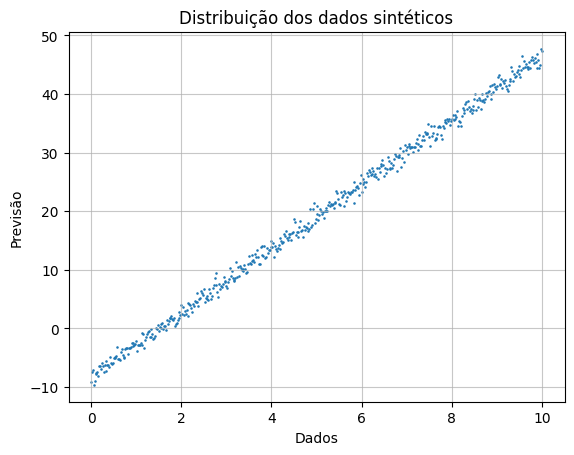

In [ ]:
B, W = np.meshgrid(b_values, w_values)

plt.scatter(x, y_true, s=0.7)

plt.title("Distribuição dos dados sintéticos")
plt.xlabel("Dados")
plt.ylabel("Previsão")

plt.grid(alpha=0.7)
plt.show()

Aqui temos uma distribuição de pontos com uma tendencia visível de desenvolvimento, porém, eles não se organizam em uma reta clara. Dado esse conjunto, nos testamos vários b's e $\omega$'s para descobrir aquele que gera a menor Loss. Na realidade, existem algoritmos determinísticos que calculam isso, o desenvolvimento é análogo ao da equação (2), caso o leitor queira ver por si mesmo. Veja abaixo como que a função de perda se comporta mudando as variáveis.

Ademais, o gráfico da regressão linear tem um termo denominado $R^2$. Não se preocupe agora, será explicado em seguida.

In [ ]:
def quadrados_minimos(w:tuple)->float:
    """
    Função de erro J(w), essa se difere da anterior pois tem o coeficiente linear

    entradas: 
    - w_ols -- Pesos totais
    saída:
    - Erro quadrático médio 
    """ 
    y_pred = x*w[1]+w[0]

    return 1/2*np.mean((y_true - y_pred)**2)
    


#Matriz que vai armazenar os erros
J = np.zeros_like(B)

menor_loss=float("inf")
coef_menor_loss = [0, 0]

for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        w_teste=[B[i, j], W[i, j]]

        J[i, j] = quadrados_minimos(w_teste)
        if menor_loss>J[i, j]:
            menor_loss = J[i, j]
            coef_menor_loss = w_teste.copy()


y_pred = coef_menor_loss[1]*x+coef_menor_loss[0]

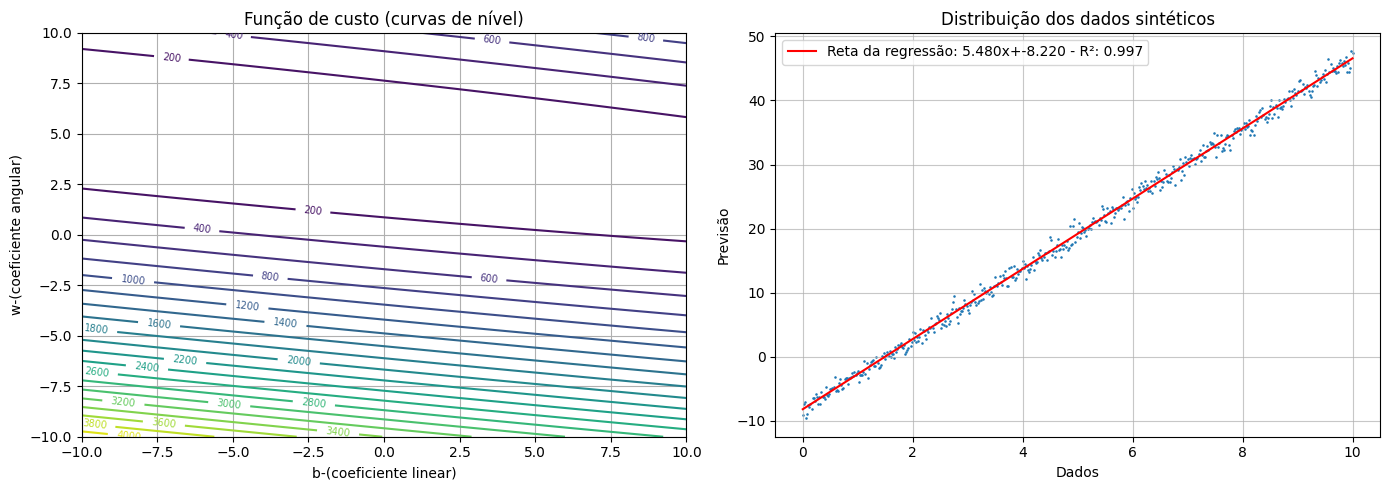

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Desenha as linhas de nível para valores constantes de J
contorno = axes[0].contour(
    B,
    W,
    J,
    levels=25
)

axes[0].clabel(contorno, inline=True, fontsize=7)

axes[0].set_xlabel("b-(coeficiente linear)")
axes[0].set_ylabel("w-(coeficiente angular)")
axes[0].set_title(
    "Função de custo (curvas de nível)"
)
axes[0].grid()

#-----------------------------------------------------------------

axes[1].scatter(x, y_true, s=0.7)
axes[1].plot(x, y_pred, label=f"Reta da regressão: {coef_menor_loss[1]:.3f}x+{coef_menor_loss[0]:.3f} - R²: {r2_score(y_true,y_pred):.3f}", color="red")

axes[1].set_title("Distribuição dos dados sintéticos")
axes[1].set_xlabel("Dados")
axes[1].set_ylabel("Previsão")

axes[1].grid(alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

A esquerda temos o gráfico com as curvas de nível da função de perda e a direita a reta da regressão. A reta encontrada é uma boa estimativa, mas não a melhor, já que não usamos a solução analítica determinísticas. Entretanto, ela serve para demonstrar o conceito. Como estimativa de erro da reta, é comumente usado três parâmetros: erro absoluto médio, erro quadrático médio e $R^2$. Os dois primeiros já foram apresentados anteriormente, mas o que é esse último?

Como estimativa da qualidade da previsão da reta, poderíamos usar o erro quadrático médio. Entretanto, esse parâmetro não da uma análise simples de forma direta, ele é quão melhor em relação a o que? Por isso, podemos dividi-lo por um outro erro quadrático médio padrão de todas as reta: chamaremos ele de baseline. 

O que é esse baseline? Imagine que façamos o seguinte modelo: para qualquer pergunta, ele responderá com a média dos valores observados. Normalmente, esse não é um bom modelo, mas ele é simples e fácil de se calcular, o suficiente para podermos usá-lo como comparativo para diversas análises: se o seu modelo é pior que esse baseline, já é uma ótima métrica para repensá-lo a fundo. Para obtermos a relação entre as estimativas, dividimos os erros médios:

$$\frac{RSS}{TSS}=\frac{\sum_{i=1}^n[y_i-y_{pred-i}]^2}{\sum_{i=1}^n[y_i-\overline{y}]^2}$$

Com:

$RSS = \sum_{i=1}^n[y_i-y_{pred-i}]^2$ sendo o **Residual Square Sum**


$TSS = \sum_{i=1}^n[y_i-\overline{y}]^2$ sendo o **Total Square Sum**

Com isso, temos formas fáceis de avaliar desempenho: se $0\leq \frac{RSS}{TSS}<1$, o modelo é melhor que o baseline em prever os resultados, se $\frac{RSS}{TSS}=1$, o modelo é tão bom quanto o baseline e se $\frac{RSS}{TSS}>1$ o modelo é pior que o baseline. Além disso, quanto mais próximo do 0, melhor a reta. Existe um último passo, para chegarmos na formula final, fazemos $R^2=1-\frac{RSS}{TSS}$. Porque? Interpretação, agora temos que o 1 é o melhor valor possível para uma reta e todos os valores acima de zero representam um modelo melhor que o baseline. Além disso, se $R^2< 0$ sabemos que o modelo é pior que o baseline e se $R^2= 0$ ele é tão bom quanto. Isso permite interpretar um $R^2=0.45$ como $45 \ %$ menos erro que o baseline. Com isso, a formula final ficaria assim:

$$R^2=1-\frac{\sum_{i=1}^n[y_i-y_{pred-i}]^2}{\sum_{i=1}^n[y_i-\overline{y}]^2}$$

<a id='toc0_'></a>[[1]](#toceq_1_)



---
### <a id='toc1_1_3_'></a>[Evidenciação do problema](#toc0_)

#### <a id='toc1_1_3_1_'></a>[Sistemas mal-condicionados](#toc0_)

Para demonstrar o problema do mal-condicionamento, imagine que tenhamos uma matriz X em que as colunas $x_1, x_2, x_3 ..., x_p$ sejam fortemente correlacionadas <a id='toc0_'></a>[[1]](#toceq_1_) <a id='toc0_'></a>[[3]](#toceq_3_), como que a predição funciona nessa situação? O exemplo a seguir não é um caso real e sim um toy-model. Ademais, ele foi feito com apenas duas variáveis, $x_1$ e $x_2$, para facilitar a visualização, mas o programa já está otimizado para $x_p$.

In [ ]:
n = 20
x1 = rng.normal(0, 1, n)
x2 = x1 + rng.normal(0, 0.08, n)

# Espaço real do problema, o normal no final é um "ruído"
y = 3*x1 + 3*x2 + rng.normal(0, 0.25, n)
X = np.column_stack([x1, x2]) # n exemplos com 2 atributos

p_shape = X.shape[1]

# centralizando os dados, se não fizermos isso, vai ter um fator de deslocamento b chamado de intercepto. Centralizando, forçamos o plano a passar por (0,0,0) e diminuímos o numero de parâmetros de (b, x1, x2) para (x1, x2) - ficaria menos didático caso não fizesse-mos.
X = X - X.mean(axis=0)
y = y - y.mean()


In [ ]:
# Tiramos o intercept na centralização, por isso o fit_intercept ta False
modelo = LinearRegression(fit_intercept=False)
modelo.fit(X, y)

# OLS é de Ordinary Least Square, ou MQO de mínimos quadrados ordinários, são os nomes usados. OLS será o nome padrão do modelo pelo notebook
#Recuperando os coeficiente
w_ols = modelo.coef_

#Fazemos genérico aqui para se voce quiser testar com mais x's
print("Coeficientes encontrados por OLS:")
for i in range(p_shape):
    print(f"w{i+1} = {w_ols[i]:.3f}")

print("\nCorrelação entre os x's:")
# O corrcoef cria uma matriz de correlação, vamos só pegar os termos superiores
matriz_correlacao = np.corrcoef(X, rowvar=False)

for i in range(p_shape):
    for j in range(i+1, p_shape):
            print(f"entre x{i+1} e x{j+1}: {matriz_correlacao[i,j]:.4f}")

Coeficientes encontrados por OLS:
w1 = 2.470
w2 = 3.509

Correlação entre os x's:
entre x1 e x2: 0.9972


Apenas para esclarecer, a correlação entre $x_1$ e $x_2$ é calculada fazendo:

$$coor(X)=\frac{\sigma_{mín}}{\sigma_{máx}}$$

<a id='toc0_'></a>[[3]](#toceq_3_)

Em que $\sigma_{máx}$ é o maior valor singular de X e $\sigma_{mín}$ é o menor valor singular de X. Quando mais próximos de 1, maior a correlação entre eles.

Nesse toy-model, correlação alta implica em mal-condicionamento, mas isso não é absoluto.

In [ ]:
# Como x1 =~ x2, temos que y=~(w1+w2)x1.
# Portanto, escolhemos pares de w1 e w2 que dão a mesma soma.

# Criamos vários pesos de soma iguais, para o caso de p_shape = 2 bastaria ter um +2 e um -2. Porém, o programa é genérico, por isso usamos a identidade de que cossenos igualmente espaçados tem soma 0.
pesos = [
    tuple(w_ols[i] for i in range(p_shape)),
    tuple(w_ols[i]+2*(np.cos(i*(2*np.pi/p_shape))) for i in range(p_shape)),
    tuple(w_ols[i]+2*(np.cos(i*(2*np.pi/p_shape)+np.pi)) for i in range(p_shape)),
]

nomes = [
    "OLS",
    f"OLS + {tuple(float(2*(np.cos(i*(2*np.pi/p_shape)))) for i in range(p_shape))}",
    f"OLS + {tuple(float(2*(np.cos(i*(2*np.pi/p_shape)+np.pi))) for i in range(p_shape))}"
]

In [ ]:
def minimum_square_error(w_ols:tuple)->float:
    """
    Função de erro J(w)

    entradas: 
    - w_ols -- Pesos totais
    saída:
    - Erro quadrático médio 
    """ 
    y_pred = X@w_ols

    return 1/2*np.mean((y - y_pred)**2)


for nome, w in zip(nomes, pesos):
    print(
        f"{nome:18s} ",
        ", ".join([f"w{i+1}={w[i]:6.2f}" for i in range(p_shape)]),
        f"MSE = {minimum_square_error(w):.4f}"
    )

OLS                 w1=  2.47, w2=  3.51 MSE = 0.0158
OLS + (2.0, -2.0)   w1=  4.47, w2=  1.51 MSE = 0.0313
OLS + (-2.0, 2.0)   w1=  0.47, w2=  5.51 MSE = 0.0313


Nota-se que J(w) não é igual para os três casos, isso é algo esperado, tendo em vista a correlação apresentada. Como a correlação de $x_1$ e $x_2$ não é 1, existe uma variação pequena quando mudamo-os. Isso indica que o vale do espaço de J(w) é achatado, mas não plano. Isso será melhor discutido no gráfico de custo abaixo.

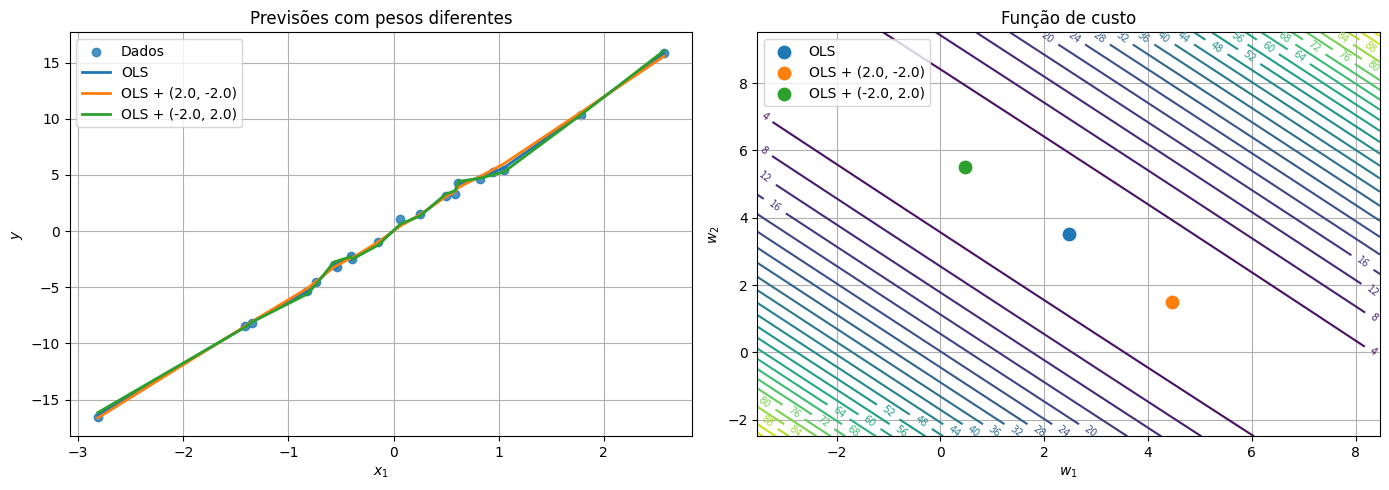

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fig 1 (previsão) --------------------------------------------------------

# Só pro gráfico ficar bonitinho, ela retorna uma lista com os indices de X ordenados. Assim, não modificamos X
ordem = np.argsort(X[:, 0])

# Como os x's são aproximadamente iguais, vamos projetar o gráfico só em x1, já que o resto dos gráficos vão ser quase que iguais
axes[0].scatter(
    X[:, 0],
    y,
    alpha=0.8,
    label="Dados"
)

for nome, w in zip(nomes, pesos):

    y_pred = sum(w[i]*X[:, i] for i in range(len(X[0])))
    # y_pred = w1*X[:, 0] + w2*X[:, 1]

    axes[0].plot(
        X[ordem, 0],
        y_pred[ordem],
        linewidth=2,
        label=f"{nome}"
    )

axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$y$")
axes[0].set_title(
    "Previsões com pesos diferentes"
)
axes[0].grid()
axes[0].legend()

# Fig 2 ------------------------------------------------------------------------

#Vamos plotar só w{l} e w{m}, mas basta mudar o índice do w_ols que você vê combinações dos outros pesos (todos são aproximadamente iguais)
#Possíveis valores de w{l} e w{m}

l=0
m=1

w1_vals = np.linspace(w_ols[l] - 6, w_ols[l] + 6, 250)
w2_vals = np.linspace(w_ols[m] - 6, w_ols[m] + 6, 250)

W1, W2 = np.meshgrid(w1_vals, w2_vals)


#Matriz que vai armazenar os erros
J = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w_teste=w_ols.copy()
        w_teste[0]=W1[i, j]
        w_teste[1]=W2[i, j]

        J[i, j] = minimum_square_error(w_teste)

# Desenha as linhas de nível para valores constantes de J
contorno = axes[1].contour(
    W1,
    W2,
    J,
    levels=25
)

axes[1].clabel(contorno, inline=True, fontsize=7)

for nome, w in zip(nomes, pesos):
    axes[1].scatter(
        w[l],
        w[m],
        s=80,
        label=nome
    )

axes[1].set_xlabel(f"$w_{l+1}$")
axes[1].set_ylabel(f"$w_{m+1}$")
axes[1].set_title(
    "Função de custo"
)
axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()


Analisando os gráficos os pontos feitos acima fazem sentido. 

As três retas do gráfico da esquerda, que são projeções da previsão multivariada, estão basicamente sobrepostas, mostrando que, mesmo com 3 conjuntos de pesos diferentes, a previsão y é quase que igual. Se houvesse apenas essas retas sem os pesos, seria quase que impossível determinar qual a melhor reta que descreve esse conjunto, confirmando o ponto levantado durante a introdução.

As 'retas' do gráfico da direita representam as curvas de nível da função de custo. No caso abordado, as curvas de nível são elipses muito alongadas, por isso tem essa aparência. Perceba que os três pontos são colineares, logo, ao colocar uma elipse extremamente alongada sobre eles nota-se que o ponto central quase que cai no mesmo nível que os outros. Isso mostra que o seus custos são extremamente próximos um dos outros, tornando difícil discernir qual a melhor reta, já que o vale é quase que plano. Isso é uma consequência da correlação ainda não é exatamente 1.0. Caso fosse, significa que preferir $x_1$ a $x_2$ não teria diferença, resultando nos tres pontos estando na exata mesma curva de nível, que seriam representadas por elipses infinitamente longas (basicamente duas retas).

Caso isso ocorresse, poderíamos representar uma variável como uma combinação linear da outra, diminuindo o número de exemplos úteis do sistema, podendo gerar, até, um sistema sub-determinado.


---
#### <a id='toc1_1_3_2_'></a>[Sistemas sub-determinados](#toc0_)


Mas isso se trata somente de sistemas mal-condicionados, e os sub-determinados?

Ele é construído de forma análoga ao visto acima, mas usando uma quantidade bem diferente de exemplos e atributos. Imagine n equações que contenham p atributos, normalmente, isso seria considerado um sistema sem solução única, e usaremos disso para demonstrar o caso exposto na introdução.

In [ ]:

n = 8   # número de exemplos
p = 20  # número de atributos

X = rng.normal(0, 1, size=(n, p))
X = X - X.mean(axis=0)

# Pesos usados para gerar os dados
w_true = rng.normal(0, 1, size=p)

# Sem ruído para evidenciar a não unicidade da solução
y = X @ w_true
y = y - y.mean()

rank = np.linalg.matrix_rank(X) # O rank da matrix é semelhante a sua dimensão (no sentido de espaço vetorial que ela define). É o número de linhas que são linearmente independentes.

print(f"Número de exemplos: {n}")
print(f"Número de atributos: {p}")
print(f"Rank de X: {rank}")

Número de exemplos: 8
Número de atributos: 20
Rank de X: 7


Note que o Rank é 7 e não 8. Tal fato pode parecer estranho, mas era esperado após centralizarmos. Quando centralizamos o sistema, forçamos o sistema a passar por um ponto definido, o que diminui o posto do problema por eliminar o termo constante da equação, o que gera uma dependência linear entre as linhas. Isso resulta na seguinte situação, há 20 atributos e 7 equações lineares, isso significa que há 13 graus de liberdade no espaço dos coeficientes que não alteram a solução do sistema <a id='toc0_'></a>[[3]](#toceq_3_). 

In [ ]:
modelo = LinearRegression(fit_intercept=False)
modelo.fit(X, y)

w_ols = modelo.coef_

print("\nErro da solução OLS:")
print(minimum_square_error(w_ols))


Erro da solução OLS:
7.442563677090034e-30


In [ ]:
# Como so queremos a solução, estamos buscando o núcleo de X. usaremos a decomposição SVD (já que a matriz é retangular)
_, _, Vt = np.linalg.svd(X, full_matrices=True)

# As linhas de Vt depois do rank formam uma base para o núcleo de X. Escolhemos uma direção qualquer do núcleo que ainda soluciona Xv=0
null_space = Vt[rank:]
v_null = null_space[0]

# Normalizamos apenas para facilitar a interpretação
v_null = v_null / np.linalg.norm(v_null)

#Isso é apenas para mostrar que Xv_null=0
print("\nNorma de X @ v_null:")
print(np.linalg.norm(X @ v_null))


Norma de X @ v_null:
7.43207042519283e-16


In [ ]:
# gerando varias soluções 
alphas = [-10, -5, 0, 5, 10]

#Aqui temos um vetor w_alpha que continua sendo solução do sistema, ja que Xv_null é zero, Xw_alpha=Xw_ols. Isso mostra que qualquer alpha soluciona o sistema
pesos = [
    w_ols + alpha * v_null
    for alpha in alphas
]

# Comparando o erro
for alpha, w in zip(alphas, pesos):

    mse = minimum_square_error(w)

    print(
        f"alpha = {alpha:>3} "
        f"MSE = {mse:.12f} "
        f"||w||₂ = {np.linalg.norm(w):.3f}"
    )


alpha = -10 MSE = 0.000000000000 ||w||₂ = 10.384
alpha =  -5 MSE = 0.000000000000 ||w||₂ = 5.730
alpha =   0 MSE = 0.000000000000 ||w||₂ = 2.799
alpha =   5 MSE = 0.000000000000 ||w||₂ = 5.730
alpha =  10 MSE = 0.000000000000 ||w||₂ = 10.384


In [ ]:
# Pegamos uma direção pertencente ao espaço de linhas de X (para não zerar)
v_signal = Vt[0]

v_signal = v_signal / np.linalg.norm(v_signal)

def custo(alpha, beta):
    """
    Função custo em duas direções
    
    entrada:
    alpha -- eixo de várias soluções com o mesmo erro
    beta -- direção para diferenciar as soluções de J(w)
    saída:
    erro da função com alpha e beta
    """
    w = (w_ols + alpha * v_null + beta * v_signal)

    return minimum_square_error(w)

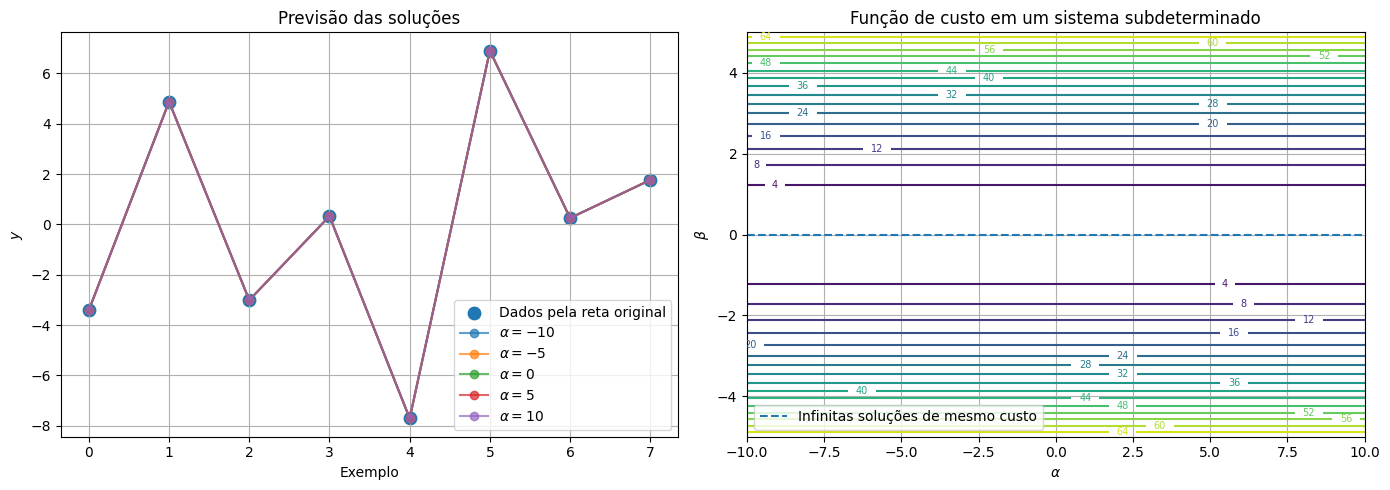

In [ ]:
alpha_vals = np.linspace(-10, 10, 200)
beta_vals = np.linspace(-5, 5, 200)

A, B = np.meshgrid(alpha_vals, beta_vals)

J = np.zeros_like(A)

for i in range(A.shape[0]):
    for j in range(A.shape[1]):

        J[i, j] = custo(
            A[i, j],
            B[i, j]
        )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fig 1 (previsões) -----------------------------------------

axes[0].scatter(
    np.arange(n),
    y,
    s=80,
    label="Dados pela reta original"
)

for alpha, w in zip(alphas, pesos):

    y_pred = X @ w

    axes[0].plot(
        np.arange(n),
        y_pred,
        marker="o",
        alpha=0.7,
        label=rf"$\alpha={alpha}$"
    )

axes[0].set_xlabel("Exemplo")
axes[0].set_ylabel("$y$")
axes[0].set_title("Previsão das soluções")

axes[0].grid()
axes[0].legend()

#Fig 2 (função custo) -------------------------------------------

contorno = axes[1].contour(
    A,
    B,
    J,
    levels=20
)

axes[1].clabel(
    contorno,
    inline=True,
    fontsize=7
)

axes[1].axhline(
    0,
    linestyle="--",
    label="Infinitas soluções de mesmo custo"
)

axes[1].set_xlabel(r"$\alpha$")
axes[1].set_ylabel(r"$\beta$")

axes[1].set_title("Função de custo em um sistema subdeterminado")

axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()

Novamente, as previsões se concretizam. A esquerda vemos um gráfico de previsões de y para oito exemplos de previsões para 5 curvas distintas. Nota-se que, mesmo para equações diferentes que usam pesos distintos, a taxa de previsão é igual, mostrando que, em sistemas sub-determinados, há mais de uma equação que gera o mesmo resultado.

Obviamente, isso é válido para pontos que fornecemos ao modelo. Para pontos fora dos exemplos podemos ter previsões distintas.

Ademais, olhando para o gráfico da esquerda, cada uma dessas soluções tem o mesmo valor de custo, somente quando saímos da solução com o $\beta$ que esse custo se altera.

Portanto, como escolher uma solução dentre infinitas soluções boas?